<a href="https://colab.research.google.com/github/mmaisa1/Medical-Text-Classification-LLMs/blob/main/Medical_Text_Classification_Using_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Medical Text Classification using LLMs (TCGA Pathology Reports)**

Methodology:
1. Load and merge TCGA pathology reports with cancer-type labels
2. Create a leakage-safe patient-disjoint train/test split
3. Run classical baselines (TF-IDF + Logistic Regression / LinearSVC)
4. Evaluate LLM-style baselines on a fixed subset (N=300):
   - Zero-shot: BART-large-MNLI (diagnosis-focused)
   - Hybrid: Top-K (SVM) candidate narrowing + chunked NLI reranking
   - Few-shot: FLAN-T5 with Top-K constrained label set
5. Train a supervised transformer baseline:
   - DistilBERT sequence classification with weighted loss (focused text)
6. Save metrics + artifacts to /results (CSVs, JSONs, plots)


**Runtime Used:**
Python 3, T4 GPU, High-RAM

In [ ]:
#Section 0 — Install + Setup + Reproducibility
!pip -q install -U transformers datasets evaluate accelerate sentencepiece
!pip -q install -U scikit-learn

import os, random, time, json, re
from pathlib import Path
from google.colab import drive
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


drive.mount("/content/drive")

FOLDER_NAME = "Medical Text Classification LLMs"

drive_root = Path("/content/drive/MyDrive")
candidates = list(drive_root.rglob(FOLDER_NAME))

if len(candidates) == 0:
    raise FileNotFoundError(
        f"Could not find '{FOLDER_NAME}' under MyDrive.\n"
        f"Steps:\n"
        f"1) Open Google Drive -> 'Shared with me'\n"
        f"2) Right-click the shared folder '{FOLDER_NAME}' -> 'Add shortcut to Drive'\n"
        f"3) Re-run this cell."
    )

PROJECT_DIR = str(candidates[0])
os.chdir(PROJECT_DIR)
print("Working dir:", os.getcwd())

RESULTS_DIR = Path(PROJECT_DIR) / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

print("CUDA available:", torch.cuda.is_available())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/Medical Text Classification LLMs
PROJECT_DIR: /content/drive/MyDrive/Medical Text Classification LLMs
RESULTS_DIR: /content/drive/MyDrive/Medical Text Classification LLMs/results
CUDA available: True


In [ ]:
# checks paths + data files
reports_path = Path(PROJECT_DIR) / "data" / "TCGA_Reports.csv"
meta_path    = Path(PROJECT_DIR) / "data" / "tcga_patient_to_cancer_type.csv"

assert reports_path.exists(), f"Missing file: {reports_path}"
assert meta_path.exists(), f"Missing file: {meta_path}"

print("Data files found:")
print(" -", reports_path)
print(" -", meta_path)


Data files found:
 - /content/drive/MyDrive/Medical Text Classification LLMs/data/TCGA_Reports.csv
 - /content/drive/MyDrive/Medical Text Classification LLMs/data/tcga_patient_to_cancer_type.csv


In [ ]:
import sys, sklearn, transformers
print("Python:", sys.version)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", __import__("datasets").__version__)
print("sklearn:", sklearn.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.10.0+cu128
transformers: 5.3.0
datasets: 4.8.2
sklearn: 1.8.0
CUDA: True
GPU: Tesla T4


In [ ]:
#Section 1 — Load , Merge TCGA , Basic CleanUp
#reports_path = f"{PROJECT_DIR}/data/TCGA_Reports.csv"
#meta_path    = f"{PROJECT_DIR}/data/tcga_patient_to_cancer_type.csv"

reports_df = pd.read_csv(reports_path)
reports_df["patient_id"] = reports_df["patient_filename"].astype(str).str.split(".").str[0]

meta_df = pd.read_csv(meta_path)

tcga_df = reports_df.merge(meta_df, on="patient_id", how="inner")
tcga_df = tcga_df.dropna(subset=["text", "cancer_type"]).reset_index(drop=True)

print("Merged rows:", len(tcga_df))
print("Unique patients:", tcga_df["patient_id"].nunique())
print("Unique cancer types:", tcga_df["cancer_type"].nunique())

# Verify one report per patient (no duplicates)
reports_per_patient = tcga_df.groupby("patient_id").size()

print("\nReports per patient distribution (top counts):")
print(reports_per_patient.value_counts().head())

assert reports_per_patient.max() == 1, "Some patients have multiple reports!"
print("✔ Verified: One report per patient.")

Merged rows: 9523
Unique patients: 9523
Unique cancer types: 32

Reports per patient distribution (top counts):
1    9523
Name: count, dtype: int64
✔ Verified: One report per patient.


In [ ]:
#Section 2 — Dataset Length Stats (Chars , Words and Tokens)
tcga_df["num_chars"] = tcga_df["text"].astype(str).str.len()
tcga_df["num_words"] = tcga_df["text"].astype(str).str.split().str.len()

print("Chars mean:", tcga_df["num_chars"].mean(), "max:", tcga_df["num_chars"].max())
print("Words mean:", tcga_df["num_words"].mean(), "max:", tcga_df["num_words"].max())
print("Words percentiles:", tcga_df["num_words"].quantile([0.5,0.75,0.9,0.95,0.99]).to_dict())

# Token stats using a transformer tokenizer
from transformers import AutoTokenizer
tokenizer_len = AutoTokenizer.from_pretrained("facebook/bart-large-mnli", use_fast=True)

def count_tokens(text: str) -> int:
    ids = tokenizer_len(text, add_special_tokens=False, truncation=False)["input_ids"]
    return len(ids)

# !!! Token counting over 9,523 docs can take time. Run once and store in cache.
tok_cache_path = RESULTS_DIR / "token_counts.npy"
if tok_cache_path.exists():
    token_counts = np.load(tok_cache_path)
else:
    token_counts = np.array([count_tokens(str(t)) for t in tcga_df["text"].tolist()], dtype=np.int32)
    np.save(tok_cache_path, token_counts)

tcga_df["num_tokens_est"] = token_counts

print("Tokens mean:", tcga_df["num_tokens_est"].mean(), "max:", tcga_df["num_tokens_est"].max())
print("Tokens percentiles:", pd.Series(tcga_df["num_tokens_est"]).quantile([0.5,0.75,0.9,0.95,0.99]).to_dict())

# Fraction exceeding BART 1024-token limit
over_1024 = (tcga_df["num_tokens_est"] > 1024).mean()

print(f"\nFraction of reports exceeding 1024 tokens: {over_1024:.3f}")

Chars mean: 3665.7224614092197 max: 26162
Words mean: 560.0436837131156 max: 4046
Words percentiles: {0.5: 432.0, 0.75: 807.5, 0.9: 1220.800000000001, 0.95: 1494.0, 0.99: 2153.8000000000065}
Tokens mean: 1046.8592880394833 max: 7011
Tokens percentiles: {0.5: 836.0, 0.75: 1477.5, 0.9: 2238.2000000000044, 0.95: 2730.7999999999993, 0.99: 3995.5600000000013}

Fraction of reports exceeding 1024 tokens: 0.398


In [ ]:
#Section 3 — Leakage-safe Train/Test Split (Patient-disjoint)
from sklearn.model_selection import GroupShuffleSplit

X = tcga_df["text"]
y = tcga_df["cancer_type"]
groups = tcga_df["patient_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train patients:", groups_train.nunique(), "Test patients:", groups_test.nunique())
print("Patient overlap:", len(set(groups_train).intersection(set(groups_test))))

# Ensure all classes appear in both train and test
missing_in_test = set(y_train.unique()) - set(y_test.unique())
missing_in_train = set(y_test.unique()) - set(y_train.unique())

print("\nClasses missing in test:", missing_in_test)
print("Classes missing in train:", missing_in_train)

assert len(missing_in_test) == 0, "Some classes missing in test!"
assert len(missing_in_train) == 0, "Some classes missing in train!"

print("✔ Verified: All classes present in both splits.")

Train size: 7618 Test size: 1905
Train patients: 7618 Test patients: 1905
Patient overlap: 0

Classes missing in test: set()
Classes missing in train: set()
✔ Verified: All classes present in both splits.



Minimum test samples per class: 8

Classes with <=5 test samples:
Empty DataFrame
Columns: [train, test]
Index: []
             train  test
cancer_type             
ACC             78    12
BLCA           302    77
BRCA           844   190
CESC           238    51
CHOL            33    10
COAD           321    97
DLBC            39     8
ESCA           116    30
GBM            312    87
HNSC           418   102


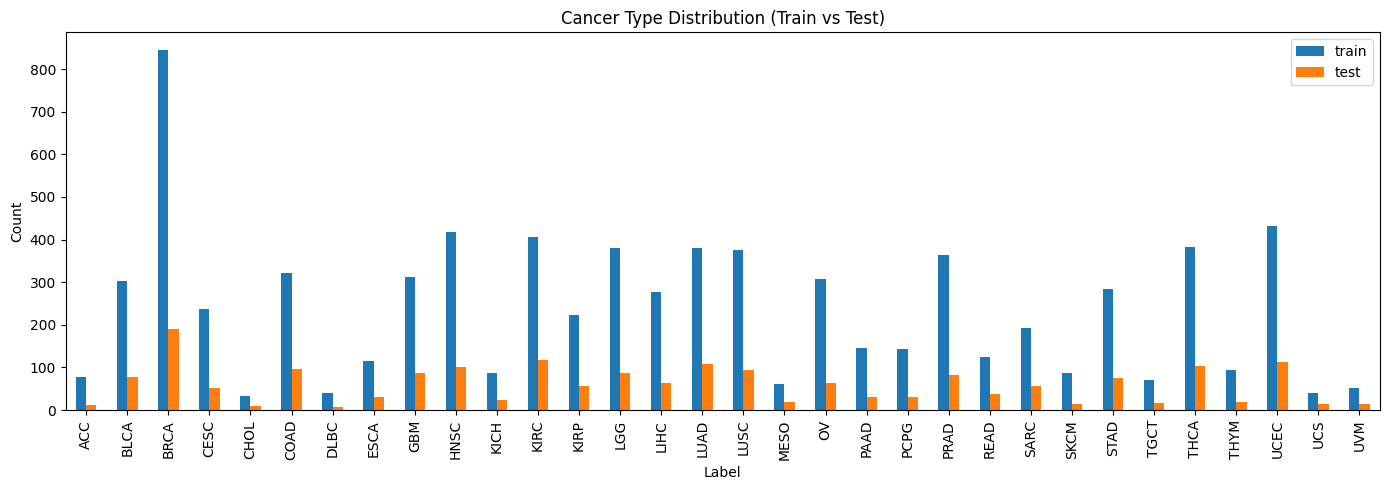


Final dataset summary:
Total samples: 9523
Train samples: 7618
Test samples: 1905
Number of classes: 32


In [ ]:
#Section 3.1 — Label Distribution (Train vs Test)
import matplotlib.pyplot as plt

train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()

dist_df = pd.DataFrame({
    "train": train_counts,
    "test": test_counts
}).fillna(0).astype(int)

print("\nMinimum test samples per class:", dist_df["test"].min())

print("\nClasses with <=5 test samples:")
print(dist_df[dist_df["test"] <= 5])

print(dist_df.head(10))
dist_df.to_csv(RESULTS_DIR / "label_distribution_train_test.csv")

ax = dist_df.plot(kind="bar", figsize=(14, 5))
ax.set_title("Cancer Type Distribution (Train vs Test)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "label_distribution_train_test.png", dpi=200)
plt.show()

print("\nFinal dataset summary:")
print("Total samples:", len(tcga_df))
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("Number of classes:", len(y_train.unique()))


In [ ]:
#Section 4 — TF-IDF Baselines (Full Test)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
NEGATION_KEEP = {"no", "not", "nor", "never", "without"}
stopwords_negation_safe = sorted(set(ENGLISH_STOP_WORDS) - NEGATION_KEEP)

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    stop_words=stopwords_negation_safe,
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr_model = LogisticRegression(
    solver="saga",
    max_iter=6000,
    n_jobs=-1,
    class_weight="balanced",
    random_state=SEED,
    C=4.0
)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

svm_model = LinearSVC(random_state=SEED, class_weight="balanced")
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

def summarize(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
    }

full_baseline_rows = [
    summarize(y_test, y_pred_lr,  "TF-IDF + LogReg (ba2lanced)"),
    summarize(y_test, y_pred_svm, "TF-IDF + LinearSVC (balanced)"),
]
full_baseline_df = pd.DataFrame(full_baseline_rows)
print(full_baseline_df)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


                           Model  Accuracy  Macro-F1  Weighted-F1
0    TF-IDF + LogReg (ba2lanced)  0.953806  0.940180     0.953954
1  TF-IDF + LinearSVC (balanced)  0.965879  0.949702     0.964771


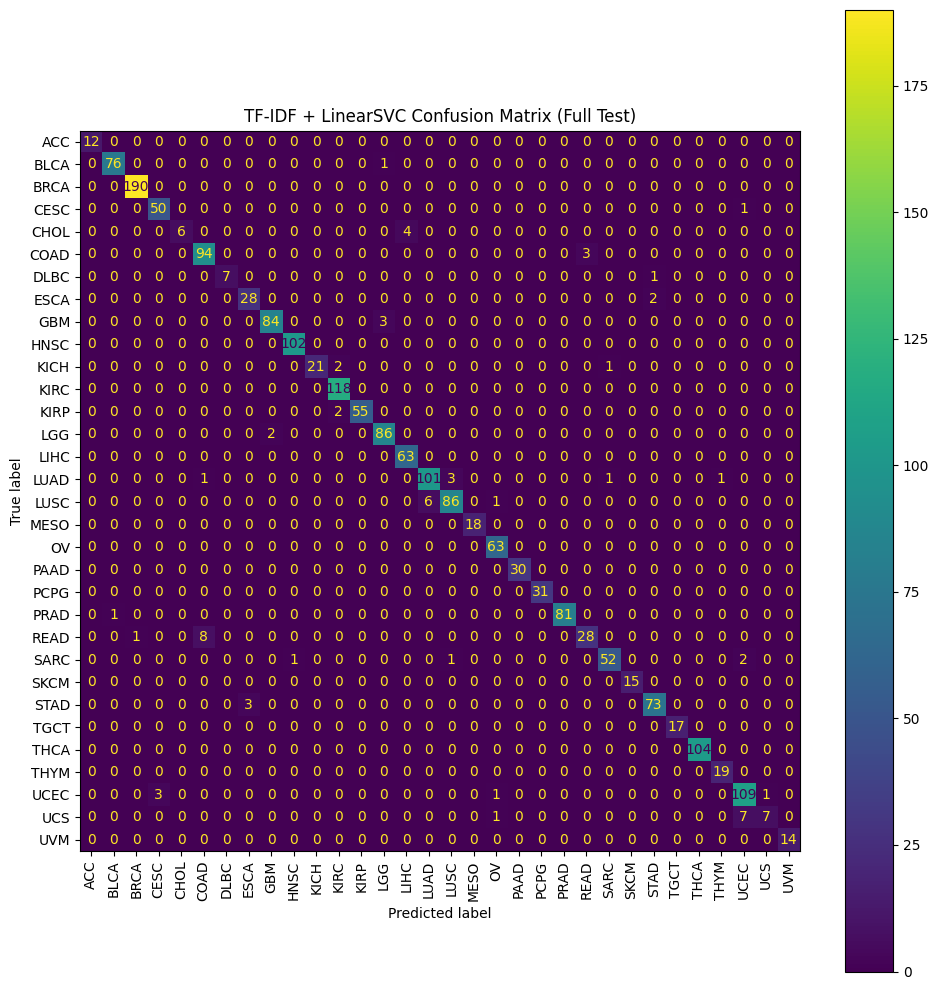

In [ ]:
#Section 4.1 — Confusion Matrices (TF-IDF Full Test)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_order = sorted(y_train.unique())  # consistent order across plots

def plot_cm(y_true, y_pred, title, out_png):
    cm = confusion_matrix(y_true, y_pred, labels=label_order)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, xticks_rotation=90, values_format=None, colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / out_png, dpi=200)
    plt.show()

#plot_cm(y_test, y_pred_lr,  "TF-IDF + LogReg Confusion Matrix (Full Test)", "cm_tfidf_logreg_full.png")
plot_cm(y_test, y_pred_svm, "TF-IDF + LinearSVC Confusion Matrix (Full Test)", "cm_tfidf_svm_full.png")

pd.DataFrame(confusion_matrix(y_test, y_pred_svm, labels=label_order),
             index=label_order, columns=label_order).to_csv(RESULTS_DIR / "cm_tfidf_svm_full.csv")


In [ ]:
#Section 5 — 5-fold Stratified Group CV Training
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_negation_safe,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="saga",
        C=4.0,
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced"
    ))
])

scores_lr = cross_validate(
    pipe_lr, X_train, y_train,
    cv=cv,
    groups=groups_train,
    scoring={"acc": "accuracy", "macro_f1": "f1_macro"},
    n_jobs=-1
)

pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_negation_safe,
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC(random_state=SEED, class_weight="balanced"))
])

scores_svm = cross_validate(
    pipe_svm, X_train, y_train,
    cv=cv,
    groups=groups_train,
    scoring={"acc": "accuracy", "macro_f1": "f1_macro"},
    n_jobs=-1
)

print("LR Group-CV acc mean±std:", scores_lr["test_acc"].mean(), scores_lr["test_acc"].std())
print("LR Group-CV macroF1 mean±std:", scores_lr["test_macro_f1"].mean(), scores_lr["test_macro_f1"].std())
print("SVM Group-CV acc mean±std:", scores_svm["test_acc"].mean(), scores_svm["test_acc"].std())
print("SVM Group-CV macroF1 mean±std:", scores_svm["test_macro_f1"].mean(), scores_svm["test_macro_f1"].std())


LR Group-CV acc mean±std: 0.9581258842972927 0.005153581152622549
LR Group-CV macroF1 mean±std: 0.9364890440419329 0.01048913633834898
SVM Group-CV acc mean±std: 0.9625896360788125 0.00647714773047546
SVM Group-CV macroF1 mean±std: 0.9453756208843096 0.006965900386766289


In [ ]:
#Section 6 — Fixed Subset (N=300)
SUBSET_N = 300
subset_path = RESULTS_DIR / "subset_idx.npy"

if subset_path.exists():
    subset_idx = np.load(subset_path)
else:
    rng = np.random.RandomState(SEED)
    subset_idx = rng.choice(len(X_test), size=min(SUBSET_N, len(X_test)), replace=False)
    np.save(subset_path, subset_idx)

subset_idx = subset_idx[:min(SUBSET_N, len(subset_idx))]

X_test_sub = X_test.iloc[subset_idx]
y_test_sub = y_test.iloc[subset_idx]
X_test_tfidf_sub = X_test_tfidf[subset_idx]

print("Subset size:", len(X_test_sub))
print("Subset unique labels:", y_test_sub.nunique())


Subset size: 300
Subset unique labels: 31


In [ ]:
# Section 6.1 — TF-IDF baselines on the fixed subset for fair comparison

# Logistic Regression
y_pred_lr_sub = lr_model.predict(X_test_tfidf_sub)

# LinearSVC
y_pred_svm_sub = svm_model.predict(X_test_tfidf_sub)

subset_baseline_rows = [
    summarize(y_test_sub, y_pred_lr_sub,  "TF-IDF + LogReg (balanced) — SUBSET"),
    summarize(y_test_sub, y_pred_svm_sub, "TF-IDF + LinearSVC (balanced) — SUBSET"),
]

subset_baseline_df = pd.DataFrame(subset_baseline_rows)
print(subset_baseline_df)
subset_baseline_df.to_csv(RESULTS_DIR / "tfidf_subset_metrics.csv", index=False)


                                    Model  Accuracy  Macro-F1  Weighted-F1
0     TF-IDF + LogReg (balanced) — SUBSET  0.950000  0.941995     0.951211
1  TF-IDF + LinearSVC (balanced) — SUBSET  0.953333  0.936360     0.949650


In [ ]:
#Extracting Key text areas to avoid contextual loss due to trunctation
def focus_text(report: str, max_chars: int = 2500):
    if report is None:
        return ""
    txt = str(report)
    lower = txt.lower()
    anchors = ["final diagnosis", "pathologic diagnosis", "diagnosis", "impression", "comment", "microscopic description"]
    start = 0
    for a in anchors:
        pos = lower.find(a)
        if pos != -1:
            start = pos
            break
    return txt[start:start + max_chars]

In [ ]:
#Section 7 — Zero-shot (BART MNLI): naive diagnosis-focused on Subset
from transformers import pipeline, AutoTokenizer

ZSHOT_MODEL = "facebook/bart-large-mnli"
tokenizer_zs = AutoTokenizer.from_pretrained(ZSHOT_MODEL, use_fast=True)
device = 0 if torch.cuda.is_available() else -1
zshot = pipeline("zero-shot-classification", model=ZSHOT_MODEL, device=device)

LABEL_MAP = {
    "ACC":"adrenocortical carcinoma",
    "BLCA":"bladder urothelial carcinoma",
    "BRCA":"breast invasive carcinoma",
    "CESC":"cervical squamous cell carcinoma and endocervical adenocarcinoma",
    "CHOL":"cholangiocarcinoma",
    "COAD":"colon adenocarcinoma",
    "DLBC":"diffuse large B-cell lymphoma",
    "ESCA":"esophageal carcinoma",
    "GBM":"glioblastoma multiforme",
    "HNSC":"head and neck squamous cell carcinoma",
    "KICH":"kidney chromophobe",
    "KIRC":"kidney renal clear cell carcinoma",
    "KIRP":"kidney renal papillary cell carcinoma",
    "LAML":"acute myeloid leukemia",
    "LGG":"brain lower grade glioma",
    "LIHC":"liver hepatocellular carcinoma",
    "LUAD":"lung adenocarcinoma",
    "LUSC":"lung squamous cell carcinoma",
    "MESO":"mesothelioma",
    "OV":"ovarian serous cystadenocarcinoma",
    "PAAD":"pancreatic adenocarcinoma",
    "PCPG":"pheochromocytoma and paraganglioma",
    "PRAD":"prostate adenocarcinoma",
    "READ":"rectum adenocarcinoma",
    "SARC":"sarcoma",
    "SKCM":"skin cutaneous melanoma",
    "STAD":"stomach adenocarcinoma",
    "TGCT":"testicular germ cell tumors",
    "THCA":"thyroid carcinoma",
    "THYM":"thymoma",
    "UCEC":"uterine corpus endometrial carcinoma",
    "UCS":"uterine carcinosarcoma",
    "UVM":"uveal melanoma",
}

label_set = sorted(y_train.unique())
missing = [c for c in label_set if c not in LABEL_MAP]
assert len(missing) == 0, f"Missing LABEL_MAP entries for: {missing}"

label_set_verbose = [LABEL_MAP[c] for c in label_set]
verbose_to_code = {LABEL_MAP[c]: c for c in label_set}

def run_zero_shot_subset(texts, labels, max_chars=2500, batch_size=8):
    focused = [focus_text(t, max_chars=max_chars) for t in texts]
    preds = []
    t0 = time.time()
    for i in range(0, len(focused), batch_size):
        batch = focused[i:i+batch_size]
        out = zshot(
            batch,
            candidate_labels=label_set_verbose,
            hypothesis_template="This pathology report describes {}.",
            truncation=True,
            max_length=1024
        )
        for o in out:
            preds.append(verbose_to_code[o["labels"][0]])
    sec = time.time() - t0
    return {
        "true": labels,
        "preds": preds,
        "acc": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "sec": sec
    }

zshot_res = run_zero_shot_subset(X_test_sub.tolist(), y_test_sub.tolist())
print(zshot_res)
with open(RESULTS_DIR / "zero_shot_subset_results.json", "w") as f:
    json.dump(zshot_res, f, indent=2)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


{'true': ['MESO', 'THCA', 'LUSC', 'LGG', 'LUSC', 'BLCA', 'ESCA', 'KIRC', 'KIRP', 'PRAD', 'LUAD', 'MESO', 'THCA', 'UCEC', 'STAD', 'MESO', 'THCA', 'THCA', 'HNSC', 'LUAD', 'LUSC', 'TGCT', 'BRCA', 'GBM', 'HNSC', 'SARC', 'THCA', 'LIHC', 'READ', 'LGG', 'PAAD', 'UVM', 'LUSC', 'LUSC', 'BLCA', 'KIRC', 'CESC', 'UCEC', 'BRCA', 'ESCA', 'KIRC', 'UCEC', 'GBM', 'LGG', 'READ', 'READ', 'UCEC', 'UCEC', 'COAD', 'BRCA', 'BLCA', 'THCA', 'BLCA', 'LGG', 'HNSC', 'LUSC', 'UCEC', 'THCA', 'PRAD', 'PCPG', 'THCA', 'SARC', 'CHOL', 'KIRC', 'PAAD', 'THCA', 'KIRC', 'BRCA', 'SARC', 'STAD', 'PRAD', 'STAD', 'PRAD', 'HNSC', 'COAD', 'BRCA', 'STAD', 'KIRC', 'KIRP', 'TGCT', 'SARC', 'HNSC', 'KIRP', 'LIHC', 'PAAD', 'LGG', 'READ', 'UCEC', 'PRAD', 'OV', 'PRAD', 'COAD', 'COAD', 'LUAD', 'UCS', 'PRAD', 'KIRC', 'LUSC', 'ESCA', 'BRCA', 'BLCA', 'COAD', 'LGG', 'HNSC', 'MESO', 'COAD', 'BRCA', 'LUAD', 'BRCA', 'KICH', 'PRAD', 'THCA', 'BRCA', 'ESCA', 'THYM', 'COAD', 'UCS', 'SARC', 'THCA', 'STAD', 'CESC', 'ACC', 'BRCA', 'SARC', 'ESCA', 'HNS

In [ ]:
#Section 8 — Hybrid Top-K + Chunked NLI rerank on Subset
def chunk_by_tokens(text: str, max_tokens=256, stride=64, max_chunks=12):
    if text is None:
        return []
    ids = tokenizer_zs(text, add_special_tokens=False, truncation=False)["input_ids"]
    chunks = []
    start = 0
    while start < len(ids) and len(chunks) < max_chunks:
        end = min(start + max_tokens, len(ids))
        chunk_txt = tokenizer_zs.decode(ids[start:end], skip_special_tokens=True)
        chunks.append(chunk_txt)
        if end == len(ids):
            break
        start = max(0, end - stride)
    return chunks

def topk_candidates_from_svm(tfidf_row, k=5):
    scores = svm_model.decision_function(tfidf_row)
    scores = np.asarray(scores).reshape(-1)
    top_idx = np.argsort(scores)[-k:][::-1]
    return [svm_model.classes_[i] for i in top_idx]

# Top-K + Chunked NLI reranking:
# Chunk the FULL report, run NLI on each chunk over Top-K candidates,
# then choose the single best (highest-confidence) chunk prediction.

def rerank_with_nli_chunks_fulltext(
    text: str,
    candidate_codes,
    max_tokens=256,
    stride=64,
    max_chunks=12
):
    # 1. Chunk FULL text by tokens
    chunks = chunk_by_tokens(
        text,
        max_tokens=max_tokens,
        stride=stride,
        max_chunks=max_chunks
    )

    # Fallback
    if not chunks:
        chunks = [str(text)]

    # 2. Convert candidate codes -> verbose labels for NLI
    cand_verbose = [LABEL_MAP[c] for c in candidate_codes]

    # 3. Best-chunk pooling:
    # For each chunk, run NLI over candidates, take the top score.
    # Across chunks, keep the single best (highest confidence) prediction.
    best_code = None
    best_score = -1.0

    for ch in chunks:
        out = zshot(
            ch,
            candidate_labels=cand_verbose,
            hypothesis_template="This pathology report describes {}.",
            truncation=True,
            max_length=1024
        )
        top_verbose = out["labels"][0]
        top_score = float(out["scores"][0])

        if top_score > best_score:
            best_score = top_score
            best_code = verbose_to_code[top_verbose]

    return best_code, best_score

def run_topk_chunked_subset(TOP_K=5, max_chunks=12):
    preds, best_scores = [], []
    t0 = time.time()

    for txt, row in zip(X_test_sub.tolist(), X_test_tfidf_sub):
        cands = topk_candidates_from_svm(row, k=TOP_K)

        pred, score = rerank_with_nli_chunks_fulltext(
            txt, cands,
            max_tokens=256,
            stride=64,
            max_chunks=max_chunks
            )
        preds.append(pred)
        best_scores.append(score)

    sec = time.time() - t0
    return {
        "TOP_K": TOP_K,
        "max_chunks": max_chunks,
        "true": y_test_sub.tolist(),
        "preds": preds,
        "acc": accuracy_score(y_test_sub, preds),
        "macro_f1": f1_score(y_test_sub, preds, average="macro"),
        "weighted_f1": f1_score(y_test_sub, preds, average="weighted"),
        "sec": sec,
        "avg_best_chunk_conf": float(np.mean(best_scores))
    }

# Sample Run : set "K" here
topk5_res = run_topk_chunked_subset(TOP_K=5, max_chunks=12)
print(topk5_res)
with open(RESULTS_DIR / f"topk{topk5_res['TOP_K']}_chunked_rerank_subset_results.json", "w") as f:
    json.dump(topk5_res, f, indent=2)


Token indices sequence length is longer than the specified maximum sequence length for this model (1269 > 1024). Running this sequence through the model will result in indexing errors


{'TOP_K': 5, 'max_chunks': 12, 'true': ['MESO', 'THCA', 'LUSC', 'LGG', 'LUSC', 'BLCA', 'ESCA', 'KIRC', 'KIRP', 'PRAD', 'LUAD', 'MESO', 'THCA', 'UCEC', 'STAD', 'MESO', 'THCA', 'THCA', 'HNSC', 'LUAD', 'LUSC', 'TGCT', 'BRCA', 'GBM', 'HNSC', 'SARC', 'THCA', 'LIHC', 'READ', 'LGG', 'PAAD', 'UVM', 'LUSC', 'LUSC', 'BLCA', 'KIRC', 'CESC', 'UCEC', 'BRCA', 'ESCA', 'KIRC', 'UCEC', 'GBM', 'LGG', 'READ', 'READ', 'UCEC', 'UCEC', 'COAD', 'BRCA', 'BLCA', 'THCA', 'BLCA', 'LGG', 'HNSC', 'LUSC', 'UCEC', 'THCA', 'PRAD', 'PCPG', 'THCA', 'SARC', 'CHOL', 'KIRC', 'PAAD', 'THCA', 'KIRC', 'BRCA', 'SARC', 'STAD', 'PRAD', 'STAD', 'PRAD', 'HNSC', 'COAD', 'BRCA', 'STAD', 'KIRC', 'KIRP', 'TGCT', 'SARC', 'HNSC', 'KIRP', 'LIHC', 'PAAD', 'LGG', 'READ', 'UCEC', 'PRAD', 'OV', 'PRAD', 'COAD', 'COAD', 'LUAD', 'UCS', 'PRAD', 'KIRC', 'LUSC', 'ESCA', 'BRCA', 'BLCA', 'COAD', 'LGG', 'HNSC', 'MESO', 'COAD', 'BRCA', 'LUAD', 'BRCA', 'KICH', 'PRAD', 'THCA', 'BRCA', 'ESCA', 'THYM', 'COAD', 'UCS', 'SARC', 'THCA', 'STAD', 'CESC', 'ACC'

In [ ]:
# --- Fixed full-label chunked NLI baseline (robust to pipeline return shape) ---
def rerank_all_labels_fulltext(text, max_tokens=256, stride=64, max_chunks=12):
    chunks = chunk_by_tokens(text, max_tokens=max_tokens, stride=stride, max_chunks=max_chunks)
    if not chunks:
        chunks = [str(text)]

    best_code = None
    best_score = -1.0

    for ch in chunks:
        # zshot may return either a dict (single input) or a list (batched input).
        out = zshot(
            ch,
            candidate_labels=label_set_verbose,
            hypothesis_template="This pathology report describes {}.",
            truncation=True
        )

        # normalize to (labels, scores) regardless of shape
        if isinstance(out, dict):
            labels = out.get("labels", [])
            scores = out.get("scores", [])
        else:
            # assume list-like with one element for this single-chunk call
            labels = out[0].get("labels", []) if len(out) > 0 else []
            scores = out[0].get("scores", []) if len(out) > 0 else []

        if not labels or not scores:
            continue

        top_verbose = labels[0]
        top_score = float(scores[0])

        if top_score > best_score:
            best_score = top_score
            best_code = verbose_to_code.get(top_verbose, None)

    return best_code, best_score

def run_fulllabel_chunked_subset(max_chunks=12, save=True):
    preds, best_scores = [], []
    t0 = time.time()
    for txt in X_test_sub.tolist():
        pred, score = rerank_all_labels_fulltext(txt, max_tokens=256, stride=64, max_chunks=max_chunks)
        preds.append(pred)
        best_scores.append(score if score is not None else 0.0)
    sec = time.time() - t0
    res = {
        "true": y_test_sub.tolist(),
        "preds": preds,
        "acc": accuracy_score(y_test_sub, preds),
        "macro_f1": f1_score(y_test_sub, preds, average="macro"),
        "weighted_f1": f1_score(y_test_sub, preds, average="weighted"),
        "sec": sec,
        "avg_best_chunk_conf": float(np.mean(best_scores)) if len(best_scores) else 0.0
    }
    if save:
        out_path = RESULTS_DIR / f"fulllabel_chunked_maxchunks{max_chunks}_results.json"
        with open(out_path, "w") as f:
            json.dump(res, f, indent=2)
        print("Saved results to:", out_path)
    return res

# run the fixed baseline (consider using max_chunks=8 to reduce runtime if needed)
fulllabel_chunked_res = run_fulllabel_chunked_subset(max_chunks=12)
print(fulllabel_chunked_res)

naive_sec = 1417.4077804088593
topk_sec  = 607.6927626132965
fulllabel_sec = fulllabel_chunked_res["sec"]
print("naive / topk =", naive_sec / topk_sec)
print("fulllabel / topk =", fulllabel_sec / topk_sec)


Saved results to: /content/drive/MyDrive/Medical Text Classification LLMs/results/fulllabel_chunked_maxchunks12_results.json
{'true': ['MESO', 'THCA', 'LUSC', 'LGG', 'LUSC', 'BLCA', 'ESCA', 'KIRC', 'KIRP', 'PRAD', 'LUAD', 'MESO', 'THCA', 'UCEC', 'STAD', 'MESO', 'THCA', 'THCA', 'HNSC', 'LUAD', 'LUSC', 'TGCT', 'BRCA', 'GBM', 'HNSC', 'SARC', 'THCA', 'LIHC', 'READ', 'LGG', 'PAAD', 'UVM', 'LUSC', 'LUSC', 'BLCA', 'KIRC', 'CESC', 'UCEC', 'BRCA', 'ESCA', 'KIRC', 'UCEC', 'GBM', 'LGG', 'READ', 'READ', 'UCEC', 'UCEC', 'COAD', 'BRCA', 'BLCA', 'THCA', 'BLCA', 'LGG', 'HNSC', 'LUSC', 'UCEC', 'THCA', 'PRAD', 'PCPG', 'THCA', 'SARC', 'CHOL', 'KIRC', 'PAAD', 'THCA', 'KIRC', 'BRCA', 'SARC', 'STAD', 'PRAD', 'STAD', 'PRAD', 'HNSC', 'COAD', 'BRCA', 'STAD', 'KIRC', 'KIRP', 'TGCT', 'SARC', 'HNSC', 'KIRP', 'LIHC', 'PAAD', 'LGG', 'READ', 'UCEC', 'PRAD', 'OV', 'PRAD', 'COAD', 'COAD', 'LUAD', 'UCS', 'PRAD', 'KIRC', 'LUSC', 'ESCA', 'BRCA', 'BLCA', 'COAD', 'LGG', 'HNSC', 'MESO', 'COAD', 'BRCA', 'LUAD', 'BRCA', 'KICH

In [ ]:
#Section 9 — Few-shot (FLAN-T5) Top-K constrained (Subset only)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

FEWSHOT_MODEL = "google/flan-t5-base"

tok_fs = AutoTokenizer.from_pretrained(FEWSHOT_MODEL)
mdl_fs = AutoModelForSeq2SeqLM.from_pretrained(FEWSHOT_MODEL)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl_fs = mdl_fs.to(device)
mdl_fs.eval()

def focus_text_fewshot(report: str, max_chars=900):
    return focus_text(report, max_chars=max_chars)

def truncate_prompt_to_max(prompt, max_input_tokens=480):
    ids = tok_fs(prompt, truncation=True, max_length=max_input_tokens).input_ids
    return tok_fs.decode(ids, skip_special_tokens=True)

# build label and train indices
train_label_to_indices = {}
y_train_list = list(y_train)
for i, lab in enumerate(y_train_list):
    train_label_to_indices.setdefault(lab, []).append(i)

rng = random.Random(SEED)

def normalize_label(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s\-_\/]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def build_prompt(test_text, candidate_labels, shots=3):
    pool = []
    for lab in candidate_labels:
        idxs = train_label_to_indices.get(lab, [])
        if idxs:
            pool.append((lab, rng.choice(idxs)))

    rng.shuffle(pool)
    pool = pool[:shots]

    examples = []
    for lab, idx in pool:
        ex_text = focus_text_fewshot(X_train.iloc[idx], max_chars=250)
        examples.append(f"Example:\nTEXT: {ex_text}\nLABEL: {lab}\n")

    test_chunk = focus_text_fewshot(test_text, max_chars=500)
    label_list = ", ".join(candidate_labels)

    prompt = (
        "Task: Predict the cancer type label for the TEXT.\n"
        f"Choose EXACTLY ONE label from this list:\n{label_list}\n\n"
        "Use the examples as guidance.\n\n"
        + "\n".join(examples)
        + f"\nNow classify:\nTEXT: {test_chunk}\nLABEL:"
    )
    return prompt

def parse_prediction(output_text, candidate_labels):
    out = normalize_label(output_text)
    cand_norm = {normalize_label(c): c for c in candidate_labels}
    if out in cand_norm:
        return cand_norm[out]
    for cn, orig in cand_norm.items():
        if cn and cn in out:
            return orig
    return None

def generate_label(prompt, max_new_tokens=12):
    inputs = tok_fs(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=480
    ).to(device)

    with torch.no_grad():
        outputs = mdl_fs.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    decoded = tok_fs.decode(outputs[0], skip_special_tokens=True)
    return decoded.strip()

def topk_from_svm(texts, k=5):
    Xv = tfidf_vectorizer.transform(texts)
    scores = svm_model.decision_function(Xv)
    topk_idx = np.argsort(scores, axis=1)[:, ::-1][:, :k]
    return topk_idx

def run_fewshot_subset(shots=3, top_k=5, max_new_tokens=12):
    test_texts = X_test_sub.tolist()
    true_labels = y_test_sub.tolist()

    topk_idx = topk_from_svm(test_texts, k=top_k)
    pred_labels, invalid = [], 0

    t0 = time.time()
    for i, txt in enumerate(test_texts):
        cand = [svm_model.classes_[j] for j in topk_idx[i]]
        prompt = truncate_prompt_to_max(build_prompt(txt, cand, shots=shots), 480)
        out = generate_label(prompt, max_new_tokens=max_new_tokens)
        pred = parse_prediction(out, cand)
        if pred is None:
            invalid += 1
            pred = cand[0]  # fallback: SVM top-1
        pred_labels.append(pred)
    sec = time.time() - t0

    return {
        "shots": shots,
        "top_k": top_k,
        "N": len(test_texts),
        "accuracy": float(accuracy_score(true_labels, pred_labels)),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")),
        "weighted_f1": float(f1_score(true_labels, pred_labels, average="weighted")),
        "invalid_rate": invalid / len(test_texts),
        "seconds_total": sec,
        "seconds_per_report": sec / len(test_texts)
    }

fewshot_results = [run_fewshot_subset(shots=s, top_k=5) for s in [1,3,5]]
fewshot_df = pd.DataFrame(fewshot_results)
print(fewshot_df)
fewshot_df.to_csv(RESULTS_DIR / "fewshot_subset_metrics.csv", index=False)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


   shots  top_k    N  accuracy  macro_f1  weighted_f1  invalid_rate  \
0      1      5  300  0.376667  0.301741     0.350593      0.023333   
1      3      5  300  0.463333  0.369844     0.454312      0.076667   
2      5      5  300  0.336667  0.271536     0.347458      0.020000   

   seconds_total  seconds_per_report  
0      27.161434            0.090538  
1      30.868419            0.102895  
2      31.382476            0.104608  


In [ ]:
# Section 10.1: Distilbert Imports and focused text extraction
# NOTE: focus_text() was defined after Section 6.1 and is reused here.

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

SEED = 42
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512  # DistilBERT hard limit




In [ ]:
#  Section 10.2: Distilbert - Group-aware split


# Validation split from TRAIN data (leakage-safe)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
tr_idx, val_idx = next(gss_val.split(X_train, y_train, groups=groups_train))

X_tr  = X_train.iloc[tr_idx].copy()
y_tr  = y_train.iloc[tr_idx].copy()

X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

X_te  = X_test.copy()
y_te  = y_test.copy()

# Applying focused text BEFORE tokenization.
X_tr_f  = X_tr.apply(focus_text)
X_val_f = X_val.apply(focus_text)
X_te_f  = X_te.apply(focus_text)

# encoding training labels
le = LabelEncoder()
y_tr_enc  = le.fit_transform(y_tr)
y_val_enc = le.transform(y_val)
y_te_enc  = le.transform(y_te)

num_labels = len(le.classes_)

# HF datasets
ds_tr  = Dataset.from_pandas(pd.DataFrame({"text": X_tr_f.tolist(),  "labels": y_tr_enc.tolist()}), preserve_index=False)
ds_val = Dataset.from_pandas(pd.DataFrame({"text": X_val_f.tolist(), "labels": y_val_enc.tolist()}), preserve_index=False)
ds_te  = Dataset.from_pandas(pd.DataFrame({"text": X_te_f.tolist(),  "labels": y_te_enc.tolist()}), preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

ds_tr_tok  = ds_tr.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_val_tok = ds_val.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_te_tok  = ds_te.map(tokenize_fn, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/6856 [00:00<?, ? examples/s]

Map:   0%|          | 0/762 [00:00<?, ? examples/s]

Map:   0%|          | 0/1905 [00:00<?, ? examples/s]

In [ ]:
# Section 10.3: Distilbert - Weighted-loss Trainer + evaluation

# Class weights computed from TRAIN split only
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_labels),
    y=y_tr_enc
)
class_weights = torch.tensor(weights, dtype=torch.float)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        cw = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = torch.nn.CrossEntropyLoss(weight=cw)(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="tmp_distilbert_focused",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,

    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=ds_tr_tok,
    eval_dataset=ds_val_tok,     # ensure validation from TRAIN data only
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    data_collator=data_collator,
)

trainer.train()

# FULL TEST evaluation
pred_te = trainer.predict(ds_te_tok)
te_logits = pred_te.predictions
te_preds  = np.argmax(te_logits, axis=-1)

acc_full = accuracy_score(y_te_enc, te_preds)
macro_full = f1_score(y_te_enc, te_preds, average="macro", zero_division=0)
weighted_full = f1_score(y_te_enc, te_preds, average="weighted", zero_division=0)

print("\nDistilBERT (weighted-loss, FOCUSED TEXT) — FULL TEST")
print("Accuracy:", acc_full)
print("Macro F1:", macro_full)
print("Weighted F1:", weighted_full)

# SUBSET (N=300) metrics from full-test logits
subset_logits = te_logits[subset_idx]
subset_preds  = np.argmax(subset_logits, axis=-1)
y_te_sub_enc  = y_te_enc[subset_idx]

acc_sub = accuracy_score(y_te_sub_enc, subset_preds)
macro_sub = f1_score(y_te_sub_enc, subset_preds, average="macro", zero_division=0)
weighted_sub = f1_score(y_te_sub_enc, subset_preds, average="weighted", zero_division=0)

print("\nDistilBERT (weighted-loss, FOCUSED TEXT) — SUBSET")
print("Accuracy:", acc_sub)
print("Macro F1:", macro_sub)
print("Weighted F1:", weighted_sub)

distilbert_results = {
    "full_test": {"acc": float(acc_full), "macro_f1": float(macro_full), "weighted_f1": float(weighted_full)},
    "subset": {"acc": float(acc_sub), "macro_f1": float(macro_sub), "weighted_f1": float(weighted_sub)},
    "notes": "DistilBERT uses focused text; timing is available in Trainer logs."
}
with open(RESULTS_DIR / "distilbert_results.json", "w") as f:
    json.dump(distilbert_results, f, indent=2)



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.103222,0.847239,0.870079,0.738181,0.849847
2,0.549786,0.451699,0.916010,0.816367,0.909330
3,0.339046,0.331273,0.927822,0.871576,0.925322


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT (weighted-loss, FOCUSED TEXT) — FULL TEST
Accuracy: 0.9275590551181102
Macro F1: 0.8857806218767439
Weighted F1: 0.927003180681724

DistilBERT (weighted-loss, FOCUSED TEXT) — SUBSET
Accuracy: 0.9166666666666666
Macro F1: 0.8805553903341432
Weighted F1: 0.9164430226526442


In [ ]:
#Section 11 — Per-class “worst classes + confusions”
from collections import Counter
from sklearn.metrics import classification_report
from IPython.display import display

def worst_classes_and_confusions(y_true, y_pred, label_order, top_n_classes=8, top_n_pairs=10):
    rpt = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    rows = []
    for cls in label_order:
        if cls in rpt:
            rows.append((cls, rpt[cls]["precision"], rpt[cls]["recall"], rpt[cls]["f1-score"], rpt[cls]["support"]))
    df = pd.DataFrame(rows, columns=["class","precision","recall","f1","support"])
    df = df.sort_values(["recall","support"], ascending=[True, True])

    print("Worst classes by recall:")
    display(df.head(top_n_classes))

    worst = df.head(min(5, len(df)))["class"].tolist()
    pairs = Counter()
    for t, p in zip(y_true, y_pred):
        if t in worst and t != p:
            pairs[(t, p)] += 1

    print("\nTop confusions among worst classes (true -> predicted):")
    for (t, p), c in pairs.most_common(top_n_pairs):
        print(f"{t} -> {p}: {c}")

# LinearSVC full test
worst_classes_and_confusions(y_test.tolist(), y_pred_svm.tolist(), label_set)


Worst classes by recall:


,class,precision,recall,f1,support
30,UCS,0.875000,0.466667,0.608696,15.0
4,CHOL,1.000000,0.600000,0.750000,10.0
22,READ,0.903226,0.756757,0.823529,37.0
6,DLBC,1.000000,0.875000,0.933333,8.0
10,KICH,1.000000,0.875000,0.933333,24.0
16,LUSC,0.955556,0.924731,0.939891,93.0
23,SARC,0.962963,0.928571,0.945455,56.0
7,ESCA,0.903226,0.933333,0.918033,30.0



Top confusions among worst classes (true -> predicted):
READ -> COAD: 8
UCS -> UCEC: 7
CHOL -> LIHC: 4
KICH -> KIRC: 2
READ -> BRCA: 1
KICH -> SARC: 1
UCS -> OV: 1
DLBC -> STAD: 1


In [ ]:
#Section 12 — Interpretability (Top LR terms for a cancer type)
import numpy as np

def top_lr_terms_for_class(lr_model, vectorizer, classes, target="BRCA", topn=15):
    if target not in classes:
        print("Target label not found:", target)
        return
    idx = list(classes).index(target)
    coef = lr_model.coef_[idx]
    top_pos = np.argsort(coef)[-topn:][::-1]
    feats = vectorizer.get_feature_names_out()

    print(f"Top {topn} terms increasing {target}:")
    for r, wid in enumerate(top_pos, 1):
        print(f"{r:2d}. {feats[wid]:<25} {coef[wid]:+.4f}")

top_lr_terms_for_class(lr_model, tfidf_vectorizer, lr_model.classes_, target="BRCA", topn=15)


Top 15 terms increasing BRCA:
 1. breast                    +9.0458
 2. ductal                    +3.6947
 3. axillary                  +3.5196
 4. sentinel                  +3.5147
 5. ductal carcinoma          +3.0271
 6. right breast              +2.6813
 7. left breast               +2.5832
 8. invasive                  +2.4921
 9. score                     +2.3830
10. carcinoma                 +2.3332
11. quadrant                  +2.1042
12. mastectomy                +2.0924
13. invasive ductal           +1.9827
14. nottingham                +1.9517
15. skin                      +1.8819
